#House Price Prediction (Regression)
The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

#Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

#Load the Dataset

In [2]:
file_path = 'house_price_regression_dataset.csv'
df = pd.read_csv(file_path)

#Check Dataset

In [3]:
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

First 5 rows of the dataset:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

Statistical Summary:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


#Handle Missing Values

In [4]:
print("Missing values before imputation:")
print(df.isnull().sum())

# Filling missing values (if any) with the median for numerical columns
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Missing values after imputation:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


#Remove Duplicate Records

In [5]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

# Drop duplicate rows
df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


#Perform Univariate Analysis

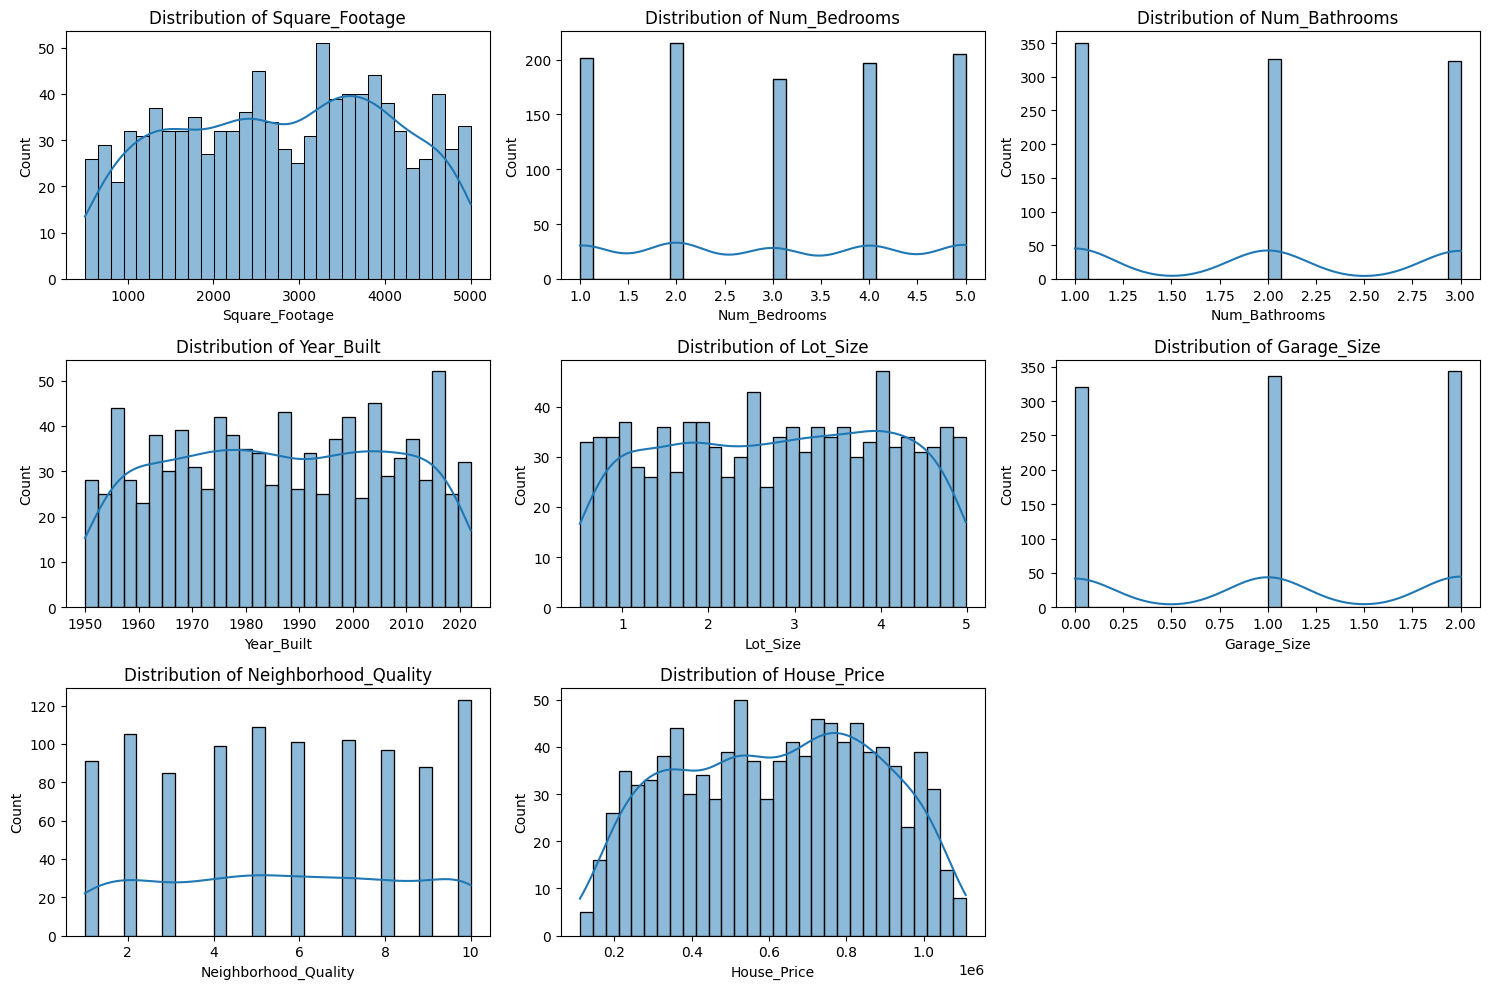

In [6]:
# Plotting histograms for all numerical columns to understand distributions
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

#Perform Bivariate Analysis

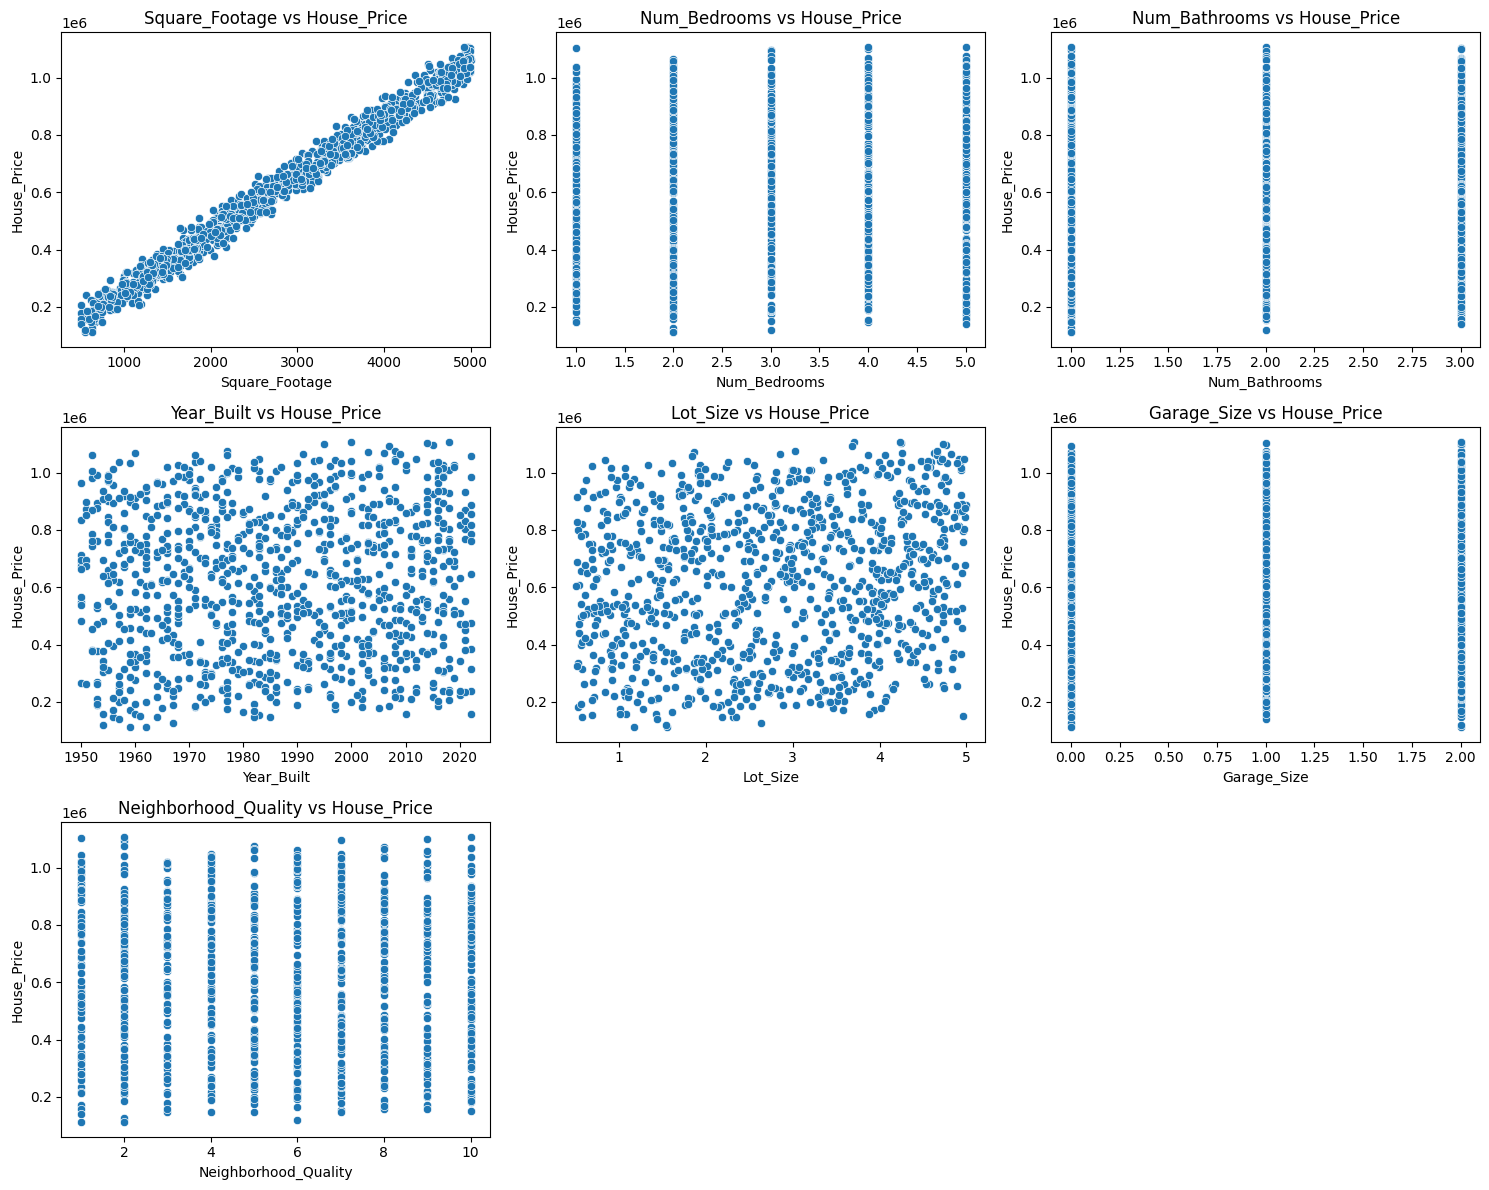

In [7]:
# Scatter plots of features vs House_Price
features = [col for col in numerical_cols if col != 'House_Price']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[feature], y=df['House_Price'])
    plt.title(f'{feature} vs House_Price')
    plt.tight_layout()
plt.show()

#Generate Correlation Heatmap

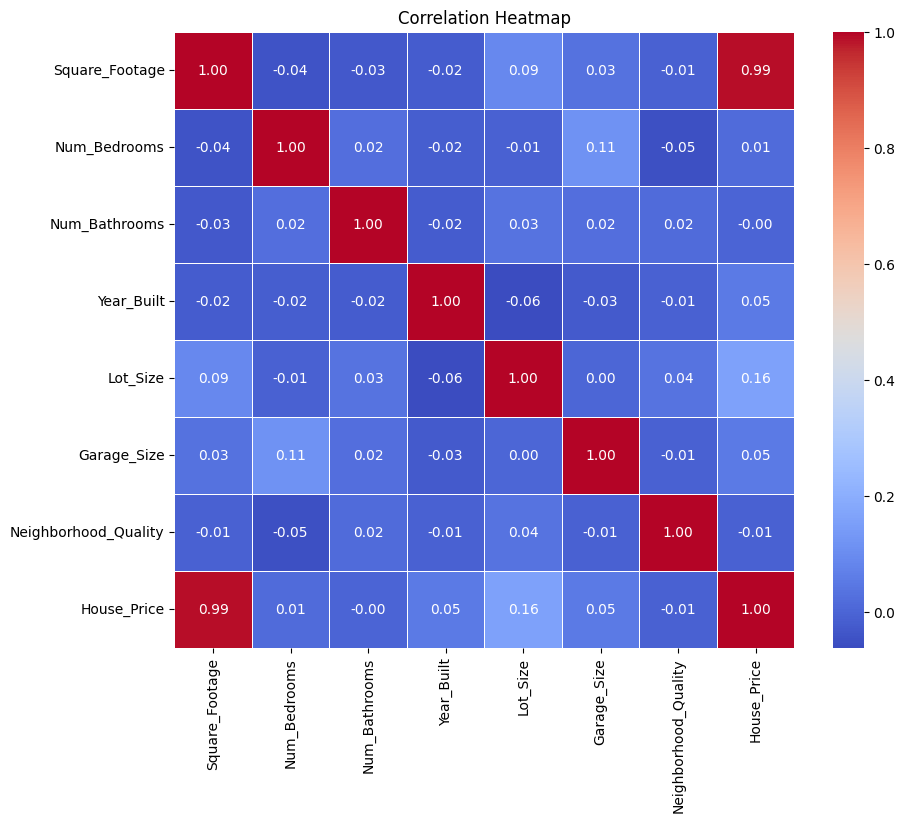

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#Detect and Handle Outliers

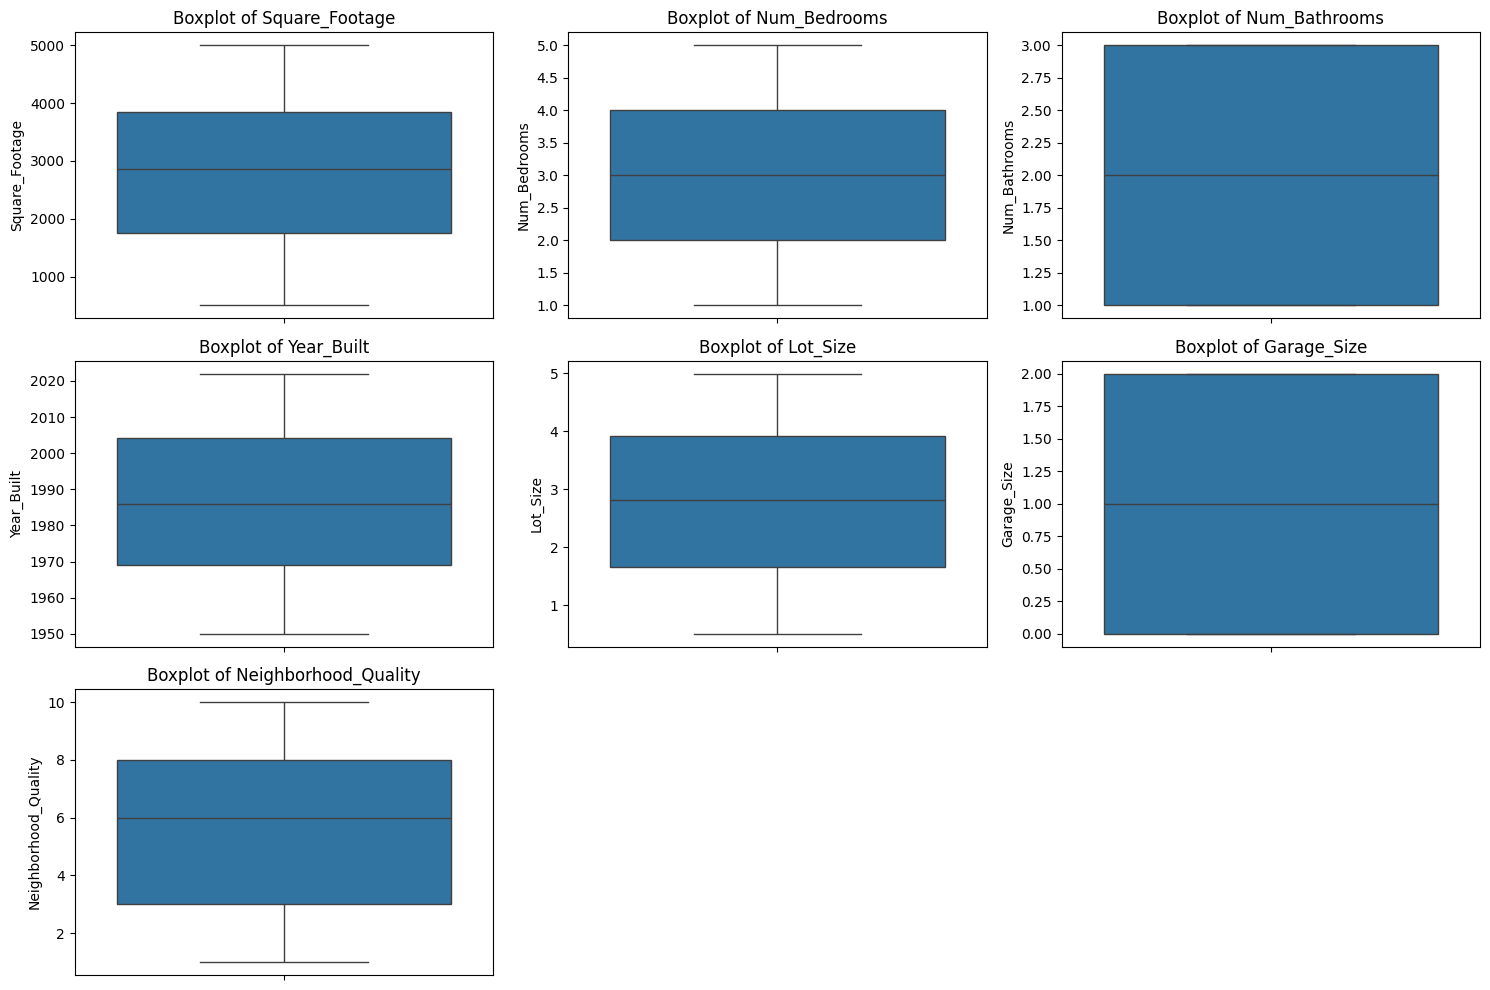

In [9]:
# Boxplots to detect outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

# Handling outliers using the IQR method
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
    return data

for feature in features:
    df = cap_outliers(df, feature)

#Apply Encoding

In [10]:
# Checking for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    print(f"Categorical columns found: {categorical_cols}. Applying One-Hot Encoding.")
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    print("No categorical variables found. Skipping encoding.")

No categorical variables found. Skipping encoding.


#Apply Log Transformation

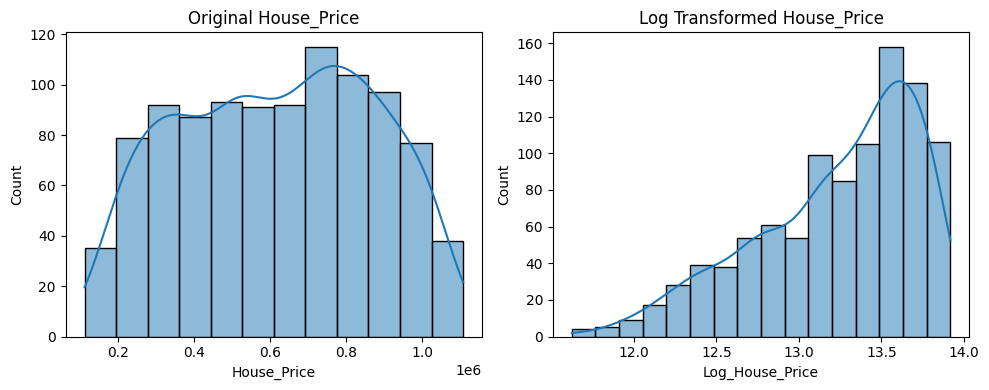

In [11]:
df['Log_House_Price'] = np.log1p(df['House_Price'])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['House_Price'], kde=True)
plt.title('Original House_Price')

plt.subplot(1, 2, 2)
sns.histplot(df['Log_House_Price'], kde=True)
plt.title('Log Transformed House_Price')
plt.tight_layout()
plt.show()



#Separate Features and Target Variable

In [12]:
X = df.drop(columns=['House_Price', 'Log_House_Price'])
y = df['House_Price']

#Perform Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing Data Shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training Data Shape: X_train: (800, 7), y_train: (800,)
Testing Data Shape: X_test: (200, 7), y_test: (200,)


#Apply Feature Scaling

In [14]:
scaler = StandardScaler()

# Fit on training set only, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to dataframe for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

#Train Regression Models

In [15]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# 2. KNN Regression
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)

#Evaluate Models Using Metrics

In [16]:
def evaluate_model(y_true, y_pred, X_data, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Adjusted R2 Calculation
    n = X_data.shape[0]
    p = X_data.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"--- Evaluation Metrics for {model_name} ---")
    print(f"MAE:         {mae:.4f}")
    print(f"MSE:         {mse:.4f}")
    print(f"RMSE:        {rmse:.4f}")
    print(f"MAPE:        {mape:.4f}")
    print(f"R2 Score:    {r2:.4f}")
    print(f"Adjusted R2: {adj_r2:.4f}\n")

evaluate_model(y_test, lr_predictions, X_test_scaled, "Linear Regression")
evaluate_model(y_test, knn_predictions, X_test_scaled, "KNN Regression")

--- Evaluation Metrics for Linear Regression ---
MAE:         8174.5836
MSE:         101434798.5056
RMSE:        10071.4844
MAPE:        0.0166
R2 Score:    0.9984
Adjusted R2: 0.9984

--- Evaluation Metrics for KNN Regression ---
MAE:         69823.2648
MSE:         6986408437.1453
RMSE:        83584.7381
MAPE:        0.1530
R2 Score:    0.8916
Adjusted R2: 0.8877

